In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\ACER\\Desktop\\Projects\\Machine Learning Based Real Estate System\\Dataset\\Cleaned_Properties_V2.csv")

In [3]:
df.head(3)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,...,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12544.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,...,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,...,NaN,60.0,59.0,0,1,0,0,0,2,7


In [4]:
df.shape

(3856, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3856 entries, 0 to 3855
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3856 non-null   object 
 1   society              3855 non-null   object 
 2   sector               3856 non-null   object 
 3   price                3838 non-null   float64
 4   price_per_sqft       3838 non-null   float64
 5   area                 3838 non-null   float64
 6   areaWithType         3856 non-null   object 
 7   bedRoom              3856 non-null   int64  
 8   bathroom             3856 non-null   int64  
 9   balcony              3856 non-null   object 
 10  floorNum             3835 non-null   float64
 11  facing               2729 non-null   object 
 12  agePossession        3856 non-null   object 
 13  super_built_up_area  1921 non-null   float64
 14  built_up_area        1777 non-null   float64
 15  carpet_area          1965 non-null   f

In [6]:
df.duplicated().sum()

128

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,...,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12544.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,...,1395.0,NaN,809.0,0,1,0,0,0,0,124


### Property Type

<Axes: xlabel='property_type'>

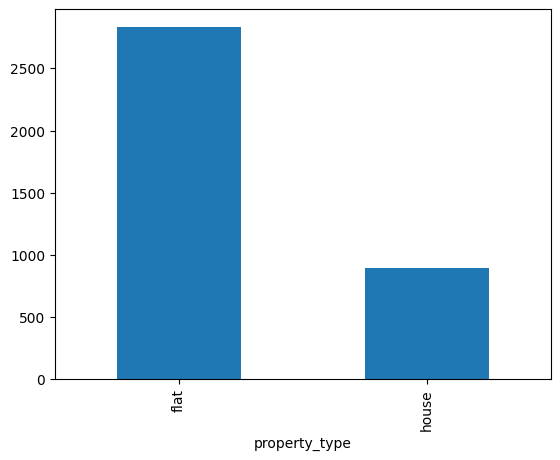

In [9]:
df['property_type'].value_counts().plot(kind='bar')

Observations

- Flats are in majority(75 percent) and there are less number of houses(~25 percent)
- No missing values

### Society

In [10]:
df['society'].value_counts().shape

(688,)

In [11]:
df['society'].value_counts()

society
independent                             517
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
krishna apartment                         1
divya apartments                          1
sobha smriti apartments                   1
navjyoti apartment                        1
shreeram apartment ii                     1
Name: count, Length: 688, dtype: int64

In [12]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75) 

society
tulip violet                            0.023364
ss the leaf                             0.046106
shapoorji pallonji joyville gurugram    0.059190
dlf new town heights                    0.072274
signature global park                   0.083178
                                          ...   
the close north                         0.487227
umang winter hills                      0.491277
ats kocoon                              0.495327
unitech uniworld resorts                0.499065
mvn athens                              0.502804
Name: proportion, Length: 75, dtype: float64

In [13]:
society_counts = df['society'].value_counts()

# Frequency Distribution for Societies
society_frequency_bins = {
    "Very High (> 100)": (society_counts > 100).sum(),
    "High (50 - 100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10 - 49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2 - 9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
society_frequency_bins

{'Very High (> 100)': 1,
 'High (50 - 100)': 2,
 'Average (10 - 49)': 92,
 'Low (2 - 9)': 279,
 'Very Low (1)': 314}

<Axes: xlabel='society'>

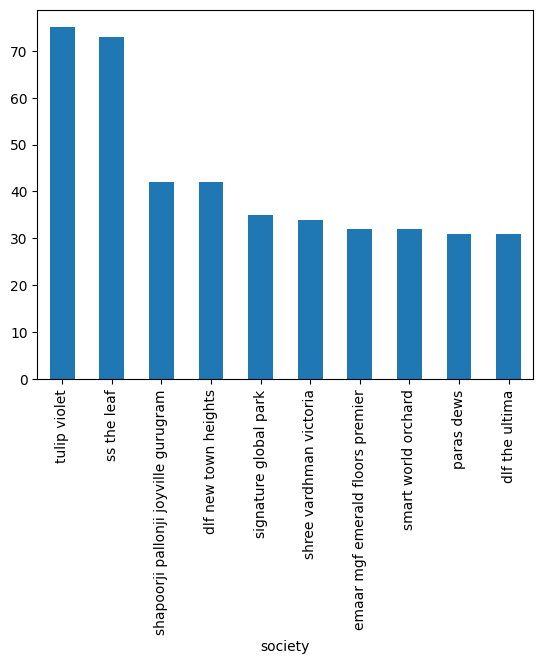

In [14]:
# Top 10 Societies

df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [15]:
df['society'].isnull().sum()

1

In [16]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1924,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,0


Observations

- Around 13% properties comes under independent tag.
- There are 675 societies.
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
    - Very High (>100): Only 1 society has more than 100 listings.
    - High (50-100): 2 societies have between 50 to 100 listings.
    - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
    - Low (2-9): 273 societies have between 2 to 9 listings.
    - Very Low (1): A significant number, 308 societies, have only 1 listing.
- 1 missing value

### Sector

In [17]:
df['sector'].value_counts().shape

(111,)

<Axes: xlabel='sector'>

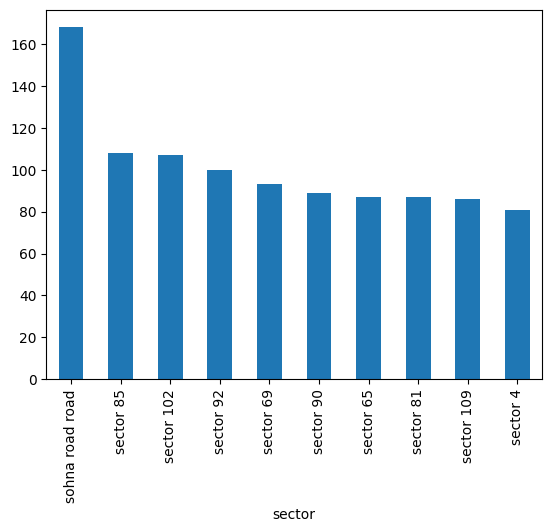

In [18]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [19]:
sector_counts = df['sector'].value_counts()

# Frequency Distribution for Societies
sector_frequency_bins = {
    "Very High (> 100)": (sector_counts > 100).sum(),
    "High (50 - 100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10 - 49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2 - 9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}
sector_frequency_bins

{'Very High (> 100)': 3,
 'High (50 - 100)': 26,
 'Average (10 - 49)': 58,
 'Low (2 - 9)': 23,
 'Very Low (1)': 1}

Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 3 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 16 sectors have between 2 to 9 listings.
    - Very Low (1): Interestingly, there are no sectors with only 1 listing.

### Price

In [20]:
df['price'].isnull().sum()

17

In [21]:
df.price.describe()

count    3711.000000
mean        2.530369
std         2.975435
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

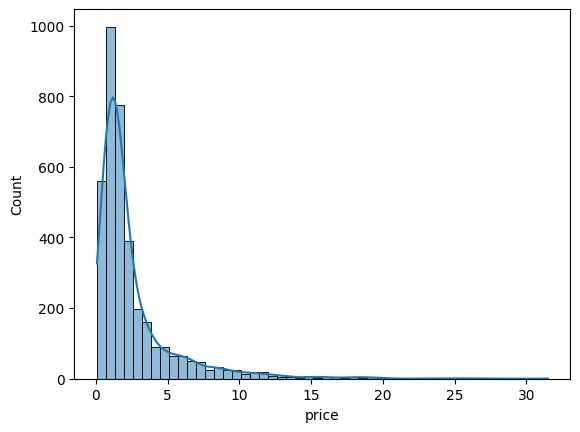

In [22]:
sns.histplot(df['price'], kde=True, bins=50)

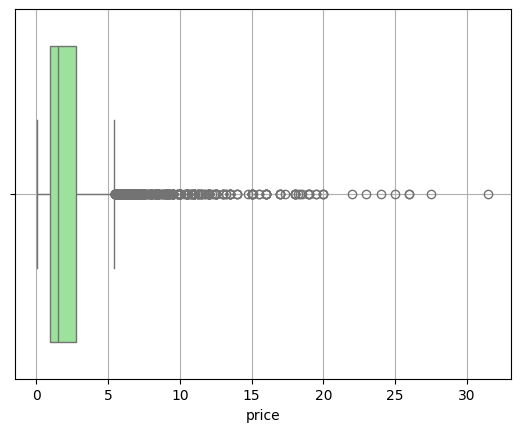

In [23]:
sns.boxplot(x = df['price'], color='lightgreen')
plt.grid()

Descriptive Statistics:

- Count: There are 3,660 non-missing price entries.
- Mean Price: The average price is approximately 2.53 crores.
- Median Price: The median (or 50th percentile) price is 1.52 crores.
- Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
- Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
- IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.


Visualizations:

- Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
- Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.


Missing Values: There are 17 missing values in the price column.

In [24]:
# Skewness and Kurtosis

skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness, kurtosis)

3.2802577708409024 14.942253563662078


<b>Skewness:</b> The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

<b>Kurtosis:</b> The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [25]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.25
0.05     0.37
0.95     8.50
0.99    15.46
Name: price, dtype: float64

Quantile Analysis:

- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.37 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [26]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']

IQR = Q3 - Q1

IQR

1.8

In [27]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [28]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(431, 23)

In [29]:
outliers['price'].describe()

count    431.000000
mean       9.214478
std        4.064876
min        5.460000
25%        6.420000
50%        8.000000
75%       10.655000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

- Based on the IQR method, there are 425 properties considered as outliers.
- These outliers have an average price of approximately 9.24 crores.
- The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

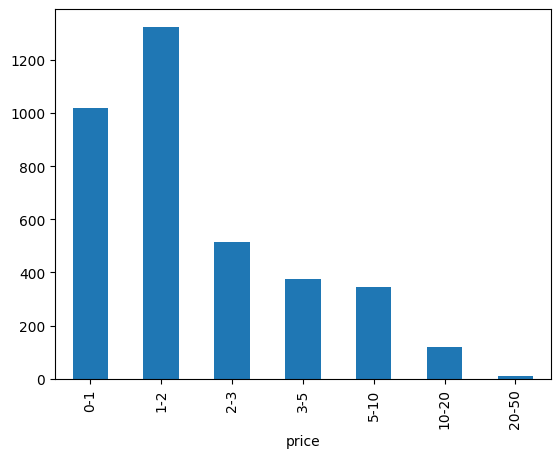

In [30]:
# Price Binning

bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

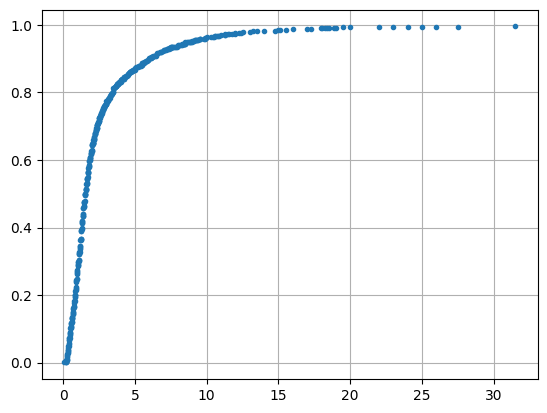

In [31]:
# ecdf Plot

ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

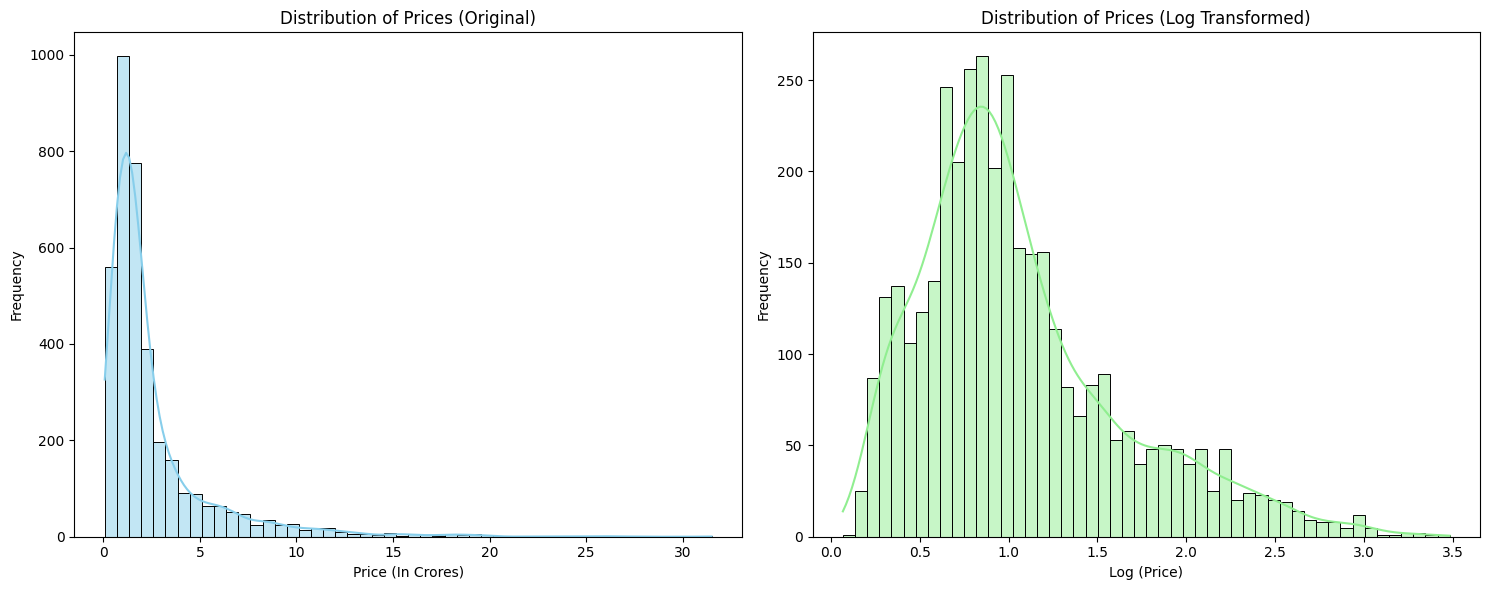

In [32]:
plt.figure(figsize=(15, 6))

# Distribution plot without Log Transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (In Crores)')
plt.ylabel('Frequency')

# Distribution plot with Log Transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log (Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [33]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness, kurtosis)

1.0712293635161143 0.9603801241394079


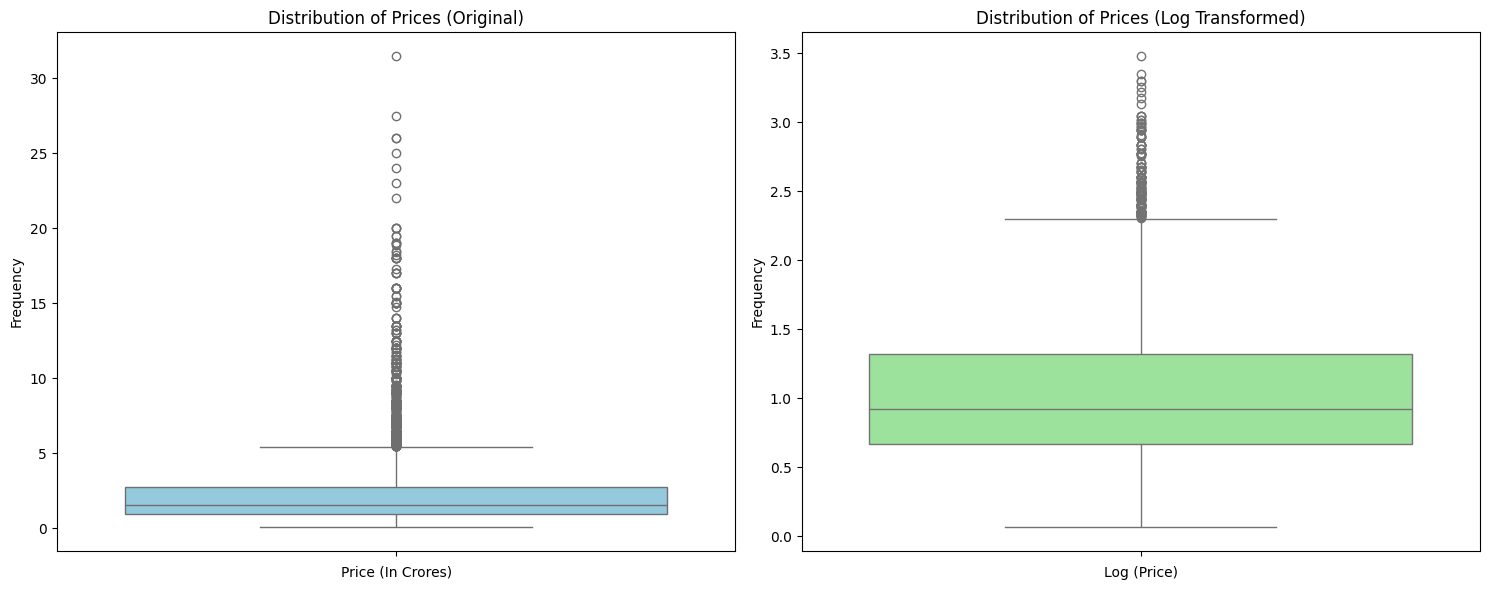

In [34]:
plt.figure(figsize=(15, 6))

# Distribution plot without Log Transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (In Crores)')
plt.ylabel('Frequency')

# Distribution plot with Log Transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log (Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Price Per SQFT

In [35]:
df['price_per_sqft'].isnull().sum()

17

In [36]:
df['price_per_sqft'].describe()

count      3711.000000
mean      13892.825115
std       23109.168677
min           4.000000
25%        6816.500000
50%        9025.000000
75%       13883.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

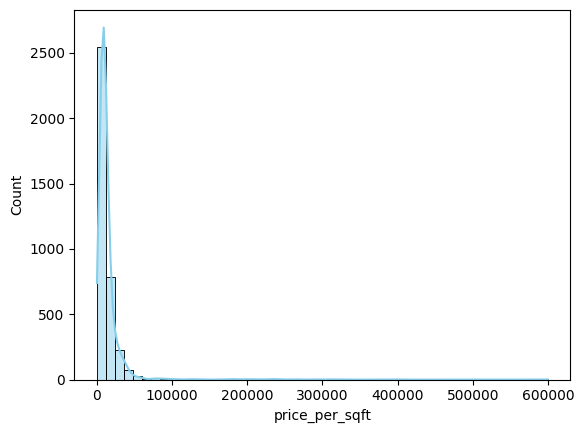

In [37]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)
plt.show()

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

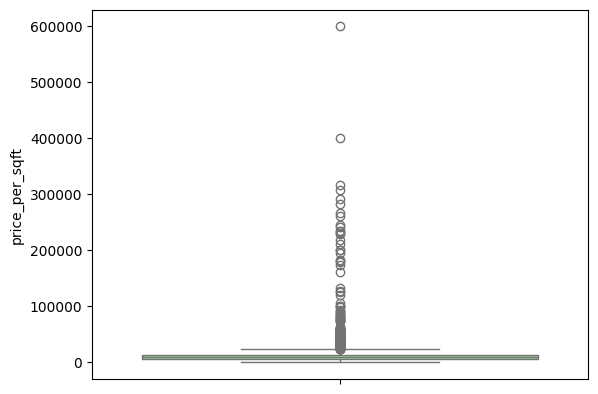

In [38]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')
plt.show()

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers.

Observations
- Potential Outliers
- Right Skewed
- 17 missing values

### bedRoom

In [39]:
df['bedRoom'].isnull().sum()

0

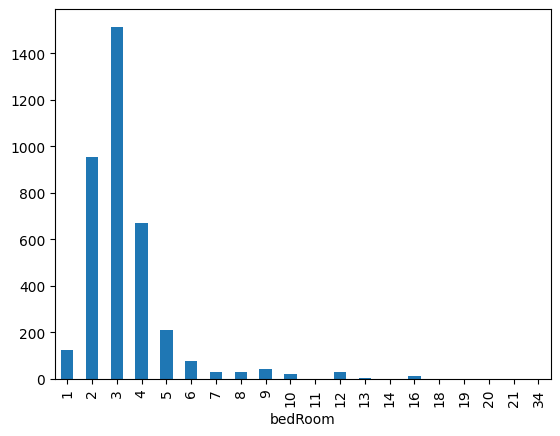

In [40]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')
plt.show()

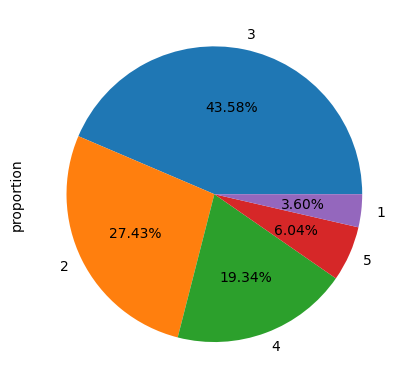

In [41]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie', autopct='%0.2f%%')
plt.show()

### bathRoom

In [42]:
df['bathroom'].isnull().sum()

0

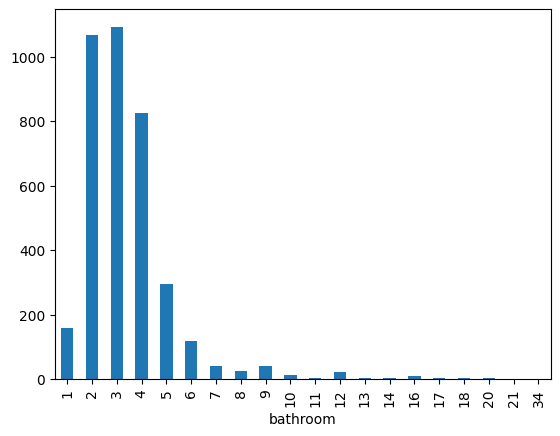

In [43]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')
plt.show()

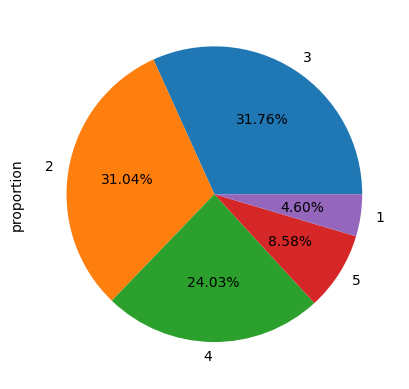

In [44]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie', autopct='%0.2f%%')
plt.show()

### balcony

In [45]:
df['balcony'].isnull().sum()

0

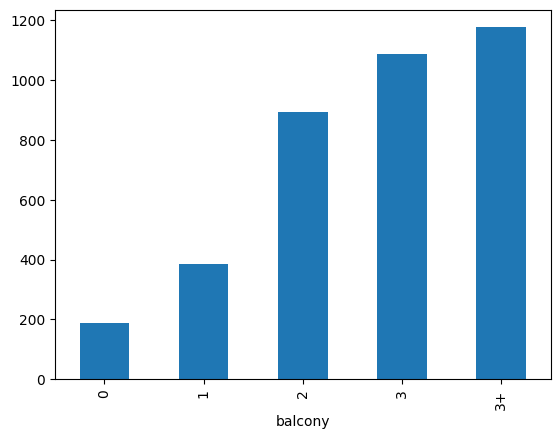

In [48]:
df['balcony'].value_counts().sort_index().plot(kind='bar')
plt.show()

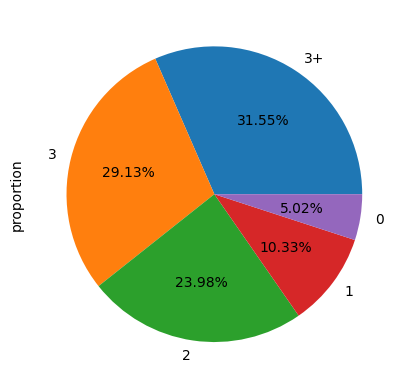

In [49]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie', autopct='%0.2f%%')
plt.show()

### floorNum

In [50]:
df.iloc[:, 10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,3.0,NaN,New Property,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,10.0,North-East,Relatively New,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,2,7
3,1.0,North-East,Undefined,NaN,3000.0,2600.0,0,0,0,0,0,1,0
4,6.0,East,New Property,2092.0,NaN,NaN,0,1,0,0,0,2,167


In [51]:
df['floorNum'].isnull().sum()

21

In [52]:
df['floorNum'].describe()

count    3707.000000
mean        6.742649
std         5.996052
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

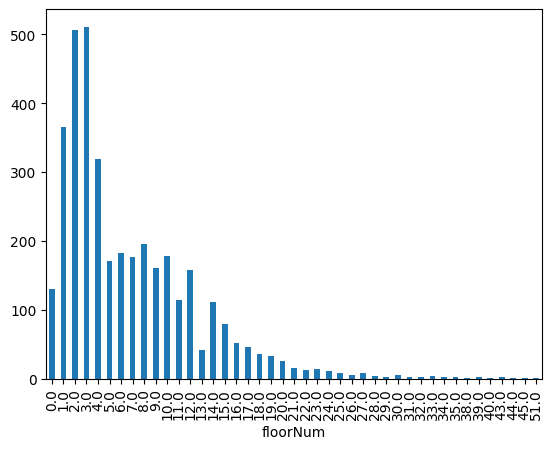

In [53]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

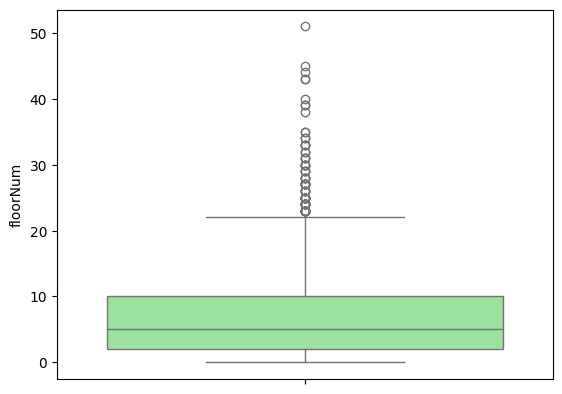

In [54]:
sns.boxplot(df['floorNum'], color='lightgreen')

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. 
- The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

### facing

In [55]:
df['facing'].isnull().sum()

1066

In [56]:
df['facing'].fillna('NA', inplace=True)

In [57]:
df['facing'].value_counts()

facing
NA            1066
North-East     636
East           631
North          391
West           249
South          232
North-West     195
South-East     175
South-West     153
Name: count, dtype: int64

### agePossession

In [58]:
df['agePossession'].isnull().sum()

0

In [59]:
df['agePossession'].value_counts()

agePossession
Relatively New        1795
New Property           622
Moderately New         573
Old Property           321
Undefined              316
Under Construction     101
Name: count, dtype: int64

### areas

In [60]:
df['super_built_up_area'].isnull().sum()

1848

In [61]:
df['super_built_up_area'].describe()

count     1880.000000
mean      1923.666782
std        763.981194
min         89.000000
25%       1477.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

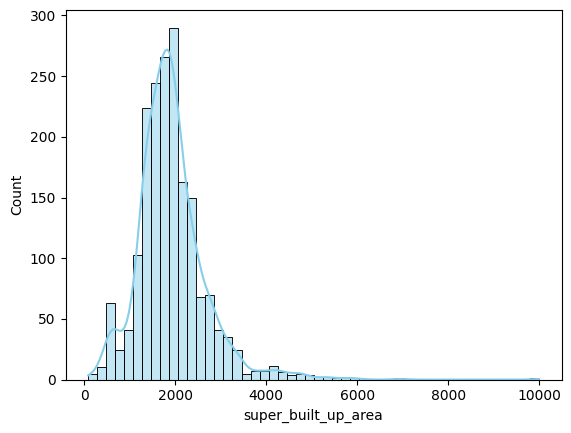

In [62]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)
plt.show()

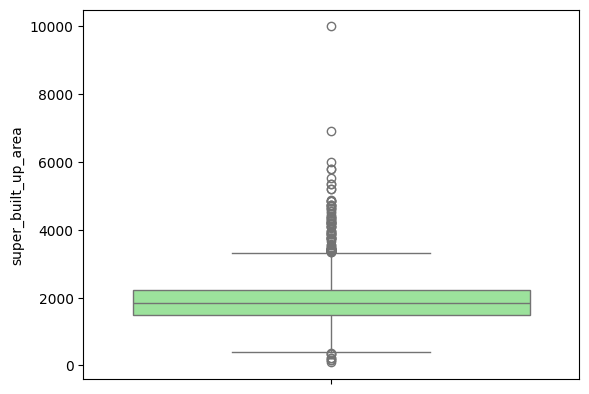

In [67]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')
plt.show()

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

### built up area

In [64]:
df['built_up_area'].isnull().sum()

1995

In [65]:
df['built_up_area'].describe()

count      1733.000000
mean       2370.751887
std       17730.064287
min           2.000000
25%        1080.000000
50%        1642.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

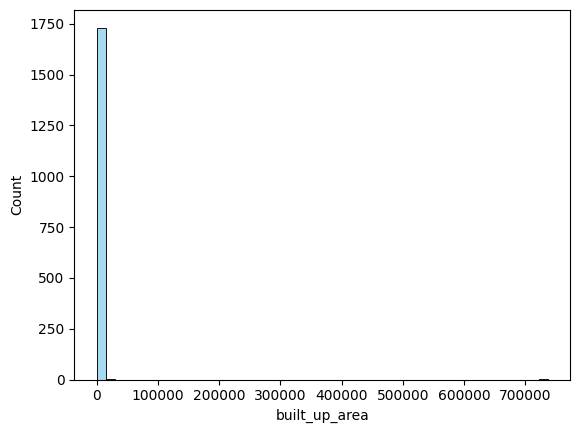

In [66]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)
plt.show()

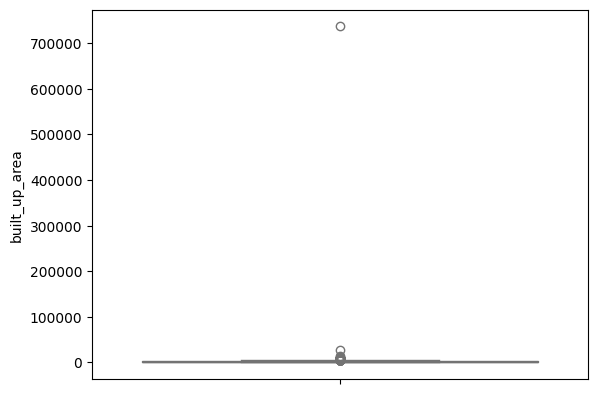

In [ ]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')
plt.show()

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. 
- The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

### carpet Area

In [69]:
df['carpet_area'].isnull().sum()

1836

In [70]:
df['carpet_area'].describe()

count      1892.000000
mean       2517.517532
std       22679.633920
min          15.000000
25%         830.000000
50%        1300.000000
75%        1795.500000
max      607936.000000
Name: carpet_area, dtype: float64

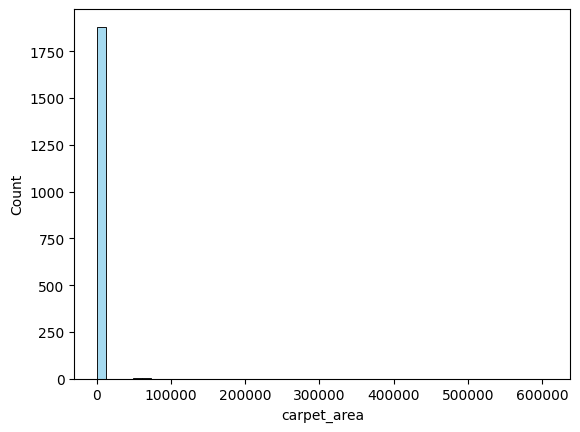

In [71]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)
plt.show()

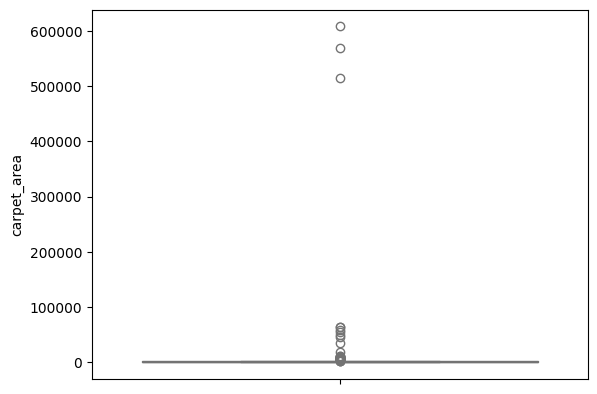

In [72]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')
plt.show()

In [73]:
df.iloc[:, 16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,1,74
1,0,1,0,0,0,0,124
2,0,1,0,0,0,2,7
3,0,0,0,0,0,1,0
4,0,1,0,0,0,2,167
...,...,...,...,...,...,...,...
3851,0,1,0,1,0,1,145
3852,0,0,0,0,0,1,57
3853,0,0,0,0,0,1,0
3854,0,1,0,0,0,1,45


### additional rooms

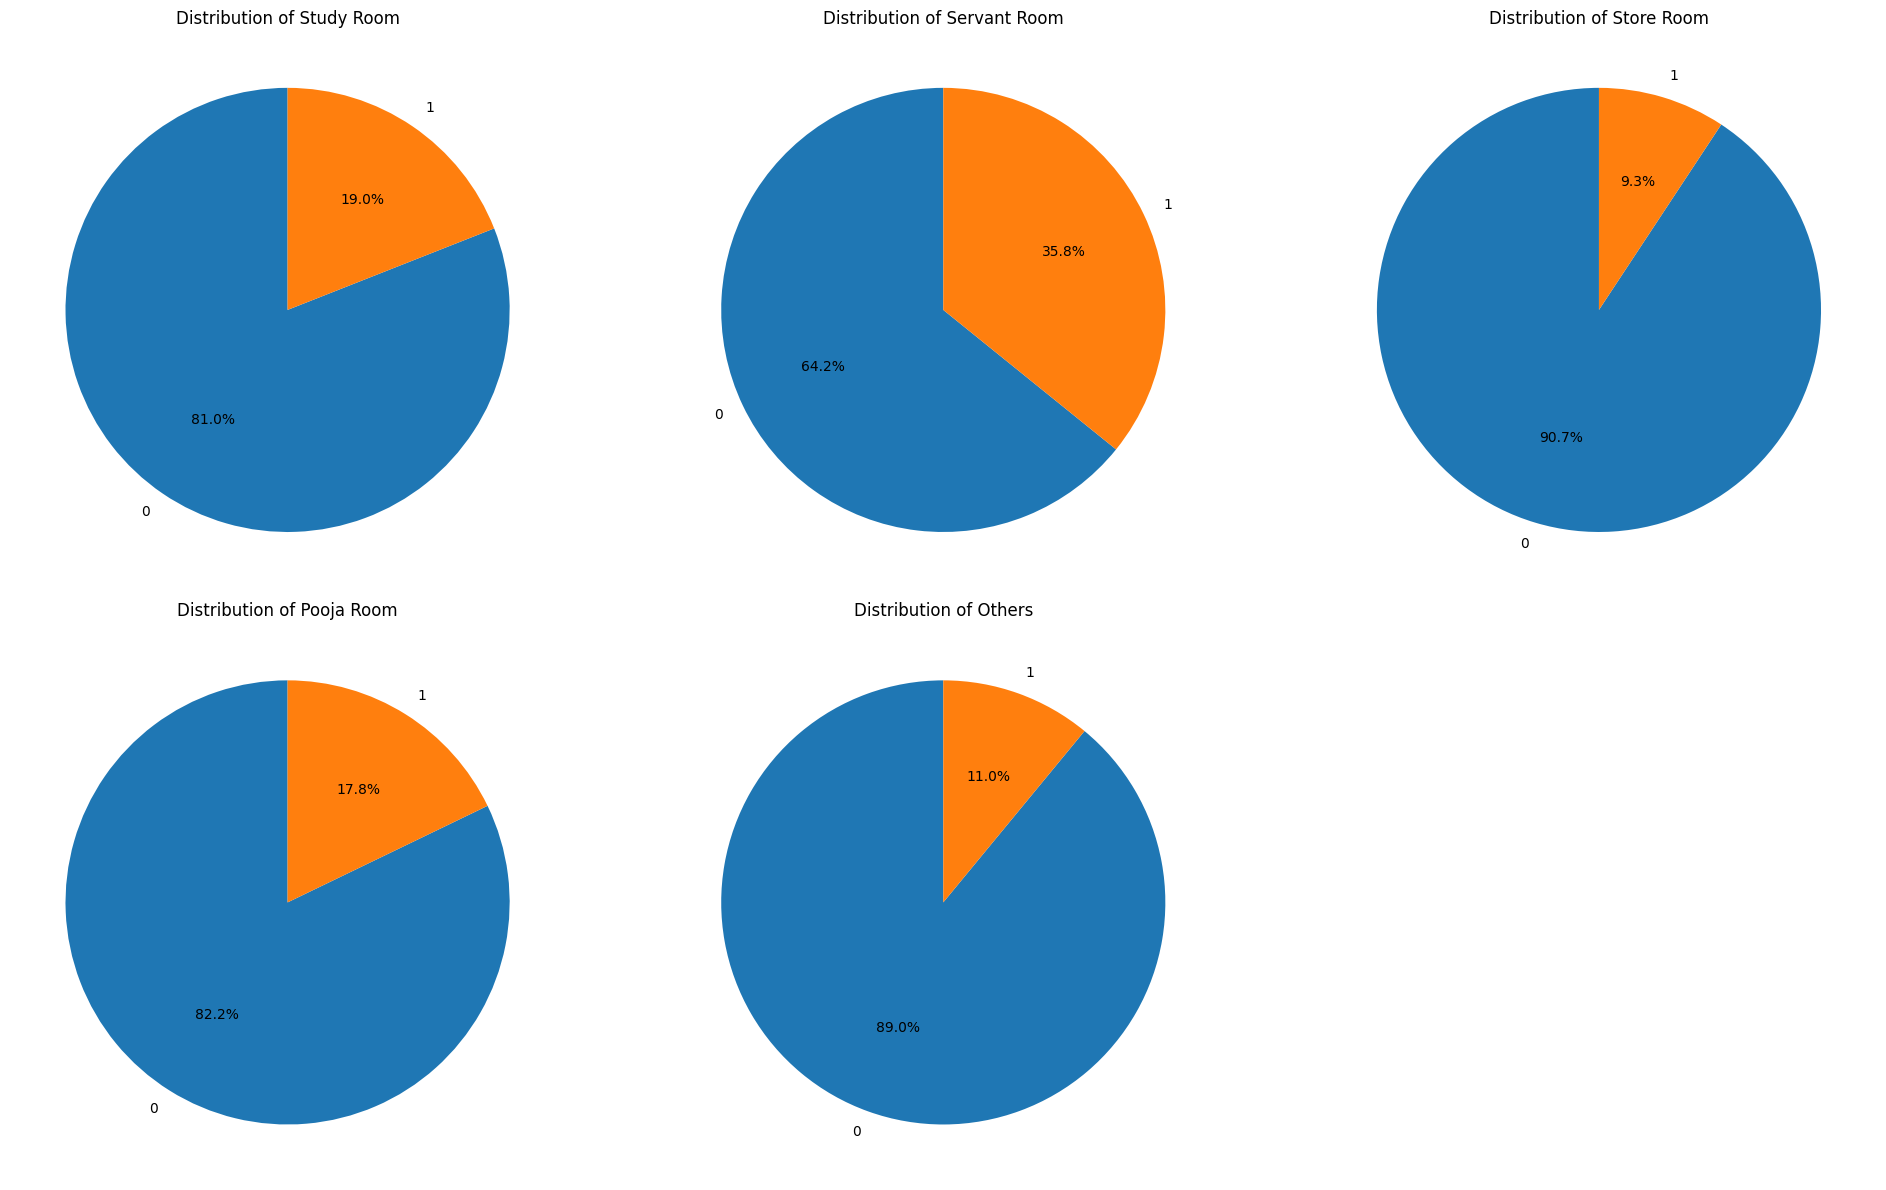

In [75]:
plt.figure(figsize=(20, 12))

# Create a subplot of Pie Charts for Each Room Type
for idx, room in enumerate(['study room', 'servant room', 'store room', 'pooja room', 'others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### furnishing_type

In [76]:
df['furnishing_type'].value_counts()

furnishing_type
1    2454
0    1068
2     206
Name: count, dtype: int64

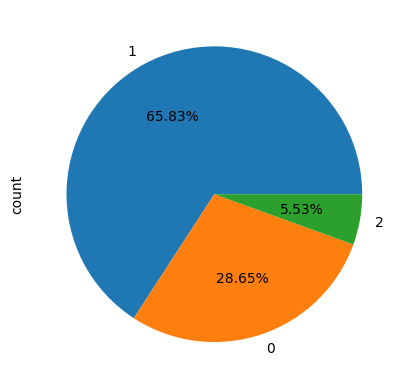

In [77]:
df['furnishing_type'].value_counts().plot(kind='pie', autopct='%0.2f%%')
plt.show()

### luxury score

In [78]:
df['luxury_score'].isnull().sum()

0

In [79]:
df['luxury_score'].describe()

count    3728.000000
mean       70.852736
std        53.118495
min         0.000000
25%        31.000000
50%        58.000000
75%       109.000000
max       174.000000
Name: luxury_score, dtype: float64

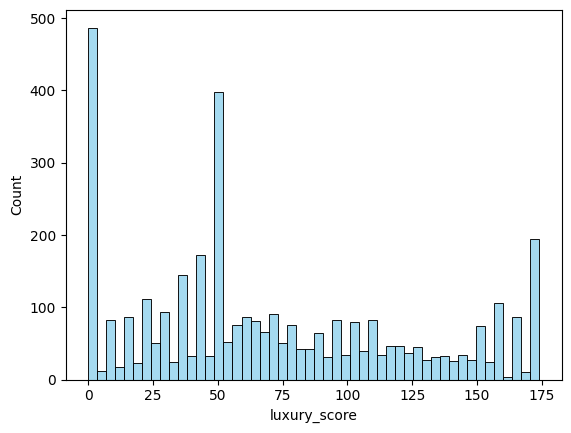

In [80]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=False)
plt.show()

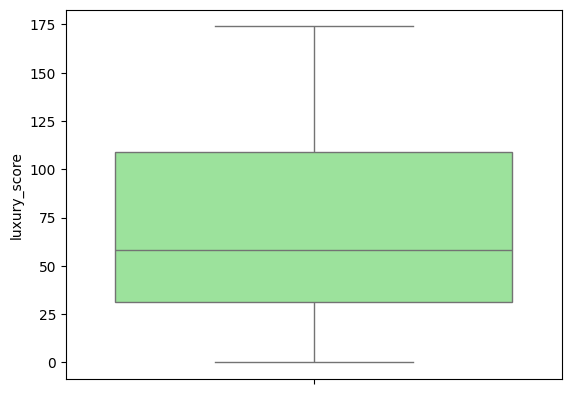

In [82]:
sns.boxplot(df['luxury_score'], color='lightgreen')
plt.show()

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [83]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,...,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12544.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,...,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,...,NaN,60.0,59.0,0,1,0,0,0,2,7
3,house,independent,sector 108,1.70,5666.0,3000.0,Built Up area: 3000 (278.71 sq.m.)Carpet area:...,4,4,3+,...,NaN,3000.0,2600.0,0,0,0,0,0,1,0
4,flat,dlf the ultima,sector 81,2.30,10994.0,2092.0,Super Built up area 2092(194.35 sq.m.),3,4,3+,...,2092.0,NaN,NaN,0,1,0,0,0,2,167
